# DASデータ前処理

このノートブックでは、Yu et al,（2024）の研究に基づいて、TDMSファイルからDAS波形データを読み込み、前処理・可視化を行う

処理内容：
- Well 78Bの対象チャネル範囲を抽出
- サンプリング周波数を4kHzから1kHzに変換
- バンドパスフィルタ（25–150 Hz）を適用
- 中央値減算によってチャネル共通ノイズを除去

In [3]:
!pip install -U gdown
!pip install -U nptdms
import pathlib as Path
import numpy as np
from nptdms import TdmsFile
from scipy.signal import butter, filtfilt, resample_poly
import matplotlib.pyplot as plt

def bandpass_filter(data, fs=1000, lowcut=25, highcut=150, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data, axis=1)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.5/181.5 kB 3.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for nptdms: filename=nptdms-1.10.0-py3-none-any.whl size=108456 sha256=37e600ab45cf7a1594b542399c87128bc7083ac1f2aa90f2af069614d117fe03
  Stored in directory: /root/.cache/pip/wheels/1b/4b/17/21e8b03b37ea51ce7ec9f5570cdf0decca93f537d61c06880f
Successfully built nptdms


In [5]:
import gdown
output = "FORGE_DFIT_UTC_20220417_105956.202.tdms"
file_id = '17yS9-oSz3pZUkVBtN52ZynAn7ti94kcj'
gdown.download(f"https://drive.google.com/uc?id={file_id}", output, quiet=False)

tdms_file = TdmsFile.read(output)

# 'Measurement' グループ内のすべてのチャンネル名を取得
group = tdms_file['Measurement']
channel_names = group.channels()

# 各チャンネルをNumPy配列として取得（チャンネル数 x データ長）
seis = np.vstack([ch.data for ch in channel_names])
print(seis.shape)


Downloading...
From (original): https://drive.google.com/uc?id=17yS9-oSz3pZUkVBtN52ZynAn7ti94kcj
From (redirected): https://drive.google.com/uc?id=17yS9-oSz3pZUkVBtN52ZynAn7ti94kcj&confirm=t&uuid=d31efbfc-7a28-47ed-9501-3ffa2a29999f
To: /content/FORGE_DFIT_UTC_20220417_105956.202.tdms
100%|██████████| 292M/292M [00:06<00:00, 48.6MB/s]
[nptdms.tdms_segment WARNING] Data size 291840000 is not a multiple of the chunk size 1050624. Will attempt to read last chunk


(2432, 60000)


- DASの総チャネル数は **2432ch**
- SilixaのSEG-Yデータに基づくと
  - **CH 70–1079** → Well 78A
  - **CH 1196–2401** → Well 78B
- 論文では **Well 78B の 1021ch** を使用（具体的範囲は記載なし）
- ノイズの多い上部・下部を除外し、**CH 1364–2384** を使用

In [6]:
# Well 78A: Channels 70–1079 (index 69–1078)
# Well 78B: Channels 1196–2401 (index 1195–2400)

# Select Well 78B data
seis78B = seis[1195:2401]  # CH 1196–2401
seis78B = seis78B[168:-17]  # CH 1364–2384 (remove noisy top/bottom)
print(seis78B.shape)


(1021, 60000)


- 信号処理ステップ：
  - **リサンプリング**：4kHz → 1kHz
  - **バンドパスフィルタ**：25–150 Hz
  - **中央値フィルタ**：共通ノイズ成分の除去

In [7]:
# Resample from 4kHz to 1kHz
downsampled_seis78B = resample_poly(seis78B.astype(np.float32), up=1, down=4, axis=1)

# Bandpass filter (25–150 Hz)
filtered_seis78B = bandpass_filter(downsampled_seis78B, fs=1000)

# Remove common-mode noise by subtracting median across channels
median_per_sample = np.median(filtered_seis78B, axis=0)
denoised_seis78B = filtered_seis78B - median_per_sample


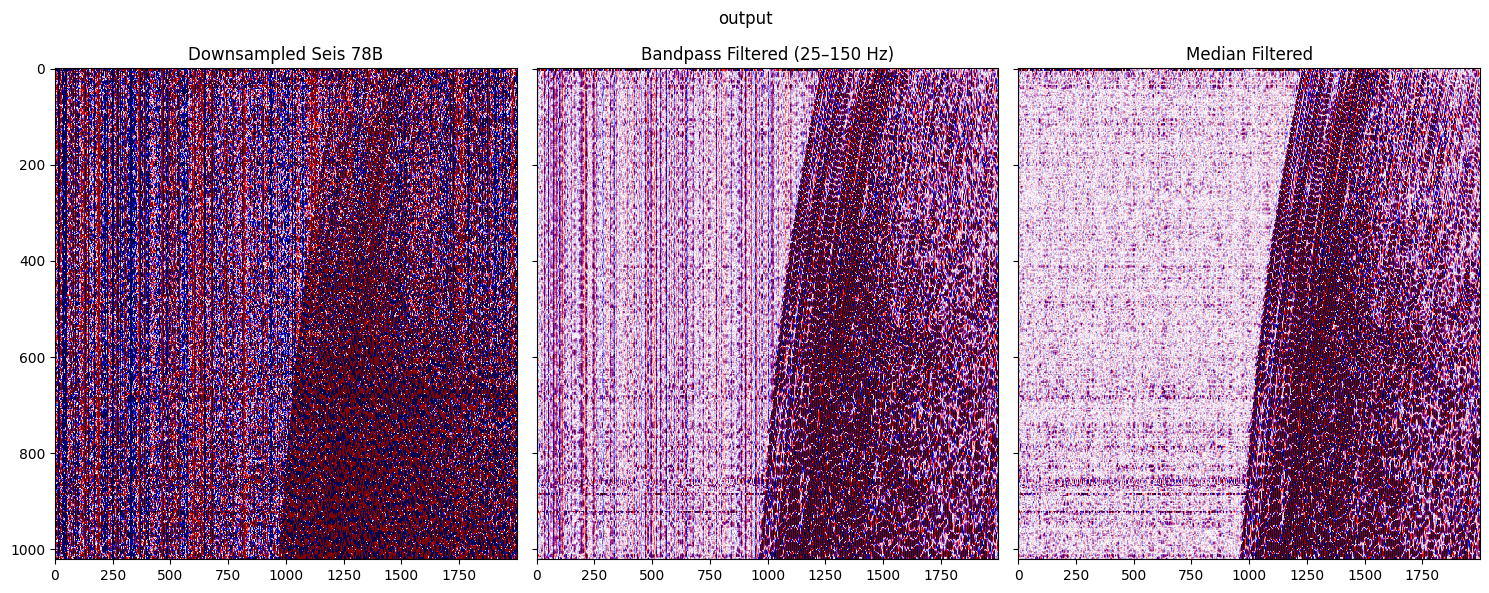

In [9]:
# Visualize
scale = 2.0
fig, ax = plt.subplots(1, 3, figsize=(15, 6), sharey=True)
ax[0].imshow(downsampled_seis78B[:, 7000:9000], aspect='auto', cmap='seismic',
             interpolation='none', vmin=-scale, vmax=scale)
ax[0].set_title('Downsampled Seis 78B')

ax[1].imshow(filtered_seis78B[:, 7000:9000], aspect='auto', cmap='seismic',
             interpolation='none', vmin=-scale, vmax=scale)
ax[1].set_title('Bandpass Filtered (25–150 Hz)')

ax[2].imshow(denoised_seis78B[:, 7000:9000], aspect='auto', cmap='seismic',
             interpolation='none', vmin=-scale, vmax=scale)
ax[2].set_title('Median Filtered')

plt.suptitle(f'output')
plt.tight_layout()
plt.show()
